# Elo Model

### Prediction and Update Formulae

Outcomes are given as a number from $0$ to $1$, where $0$ means the player/team on the left lost whilst $1$ means they won. If the outcome is $0.5$, we have a draw, and any number in between represents a win probability.

In [102]:
def expected_outcome(elo_a: float, elo_b: float, scale: int = 400) -> float:
    """
    :param elo_a: First team's elo.
    :param elo_b: Second team's elo.
    :param scale: Elo difference between players to give 10:1 odds to the higher player.
    :return: Chance of player A winning the game.
    """
    rb_ra: float = (elo_b - elo_a) / scale
    return 1 / (1 + 10 ** rb_ra)

In [103]:
def new_elos(elo_a: float, elo_b: float, outcome: float, k_factor: int = 16) -> tuple[float, float]:
    """
    :param elo_a: First team's elo.
    :param elo_b: Second team's elo.
    :param outcome: Which player won. Traditionally it is a simple win/loss, but we use a float that gives information on the margin of victory as well (the fraction of points scored by the first team).
    :param k_factor: Maximum elo change allowed after a game, limiting volatility.
    :return: The updated elos of both players after the game.
    """
    diff: float = k_factor * (outcome - expected_outcome(elo_a, elo_b))
    return elo_a + diff, elo_b - diff

In [104]:
def kelly_criterion(probability: float, odds: float = 2.0, fraction: float = 1.0) -> float:
    """
    :param probability: The win probability.
    :param odds: Given odds for the team to win. By default, we consider the odds to be even (for backtesting).
    :param fraction: What fraction of the Kelly formula's output to bet.
    :return: The percentage of the account to bet. With even odds, this is 2p - 1.
    """
    return fraction * (probability - (1 - probability) / (odds - 1))

### Load Data

First cell formats the raw data and extracts the teams, second cell splits data into training and test.

In [105]:
from pandas import DataFrame, Series
import pandas as pd

raw: DataFrame = pd.read_csv("data/nba_team_reference.csv")
raw["points_ratio"] = raw["pts_home"] / (raw["pts_home"] + raw["pts_away"]) # Tells us which team won and by how much (ratio < 0.5 means home team lost).
raw.drop(columns=["season_year", "team_id_home", "team_id_away", "pts_home", "pts_away", "home_win"], inplace=True) # Formatting the data...
raw.rename(columns={"game_id": "id", "game_date": "date", "team_abbreviation_home": "home", "team_abbreviation_away": "away"}, inplace=True)

teams: dict[str, float] = dict((team, 1000) for team in set(raw["home"].tolist() + raw["away"].tolist())) # Retrieve all team identifiers and start at 1000 elo.

assert len(teams) == 30 # NBA has 30 teams.

In [106]:
# Split data into training (first 80% of games) and test (the remaining 20%).
training: DataFrame = raw[:int(len(raw) * 0.9)]
test:     DataFrame = raw[~raw["id"].isin(training["id"])]

assert len(training) + len(test) == len(raw)                     # Check the total number of games is still the same.
assert len(test["id"].isin(training["id"]).value_counts()) == 1  # Ensure no overlap between training and test games.

### Train

Go over each game in order and update team elos.

[('BOS', 1015.385362205583), ('OKC', 1011.7952172239683), ('DAL', 1009.1043176124839), ('NYK', 1007.377265493517), ('MIN', 1006.8951164126154), ('GSW', 1006.3484905648373), ('DEN', 1005.4859957898492), ('ORL', 1004.9554828380939), ('CLE', 1004.690147416816), ('HOU', 1003.9391376893698), ('PHX', 1003.4785093189864), ('LAC', 1003.452393705307), ('SAC', 1002.3427019357742), ('MIL', 1002.081637171113), ('MIA', 1001.2514609374556), ('IND', 999.5442483643227), ('LAL', 999.228820606666), ('MEM', 999.1864838292304), ('PHI', 998.468994202413), ('CHI', 997.9928569302019), ('ATL', 996.3729676570531), ('SAS', 994.9559764611655), ('NOP', 994.8541519209092), ('BKN', 994.0768588037703), ('TOR', 992.7373461257013), ('UTA', 991.3407410310728), ('DET', 989.8133939000193), ('CHA', 989.1009201219567), ('POR', 987.6473642508424), ('WAS', 986.0956394789051)]


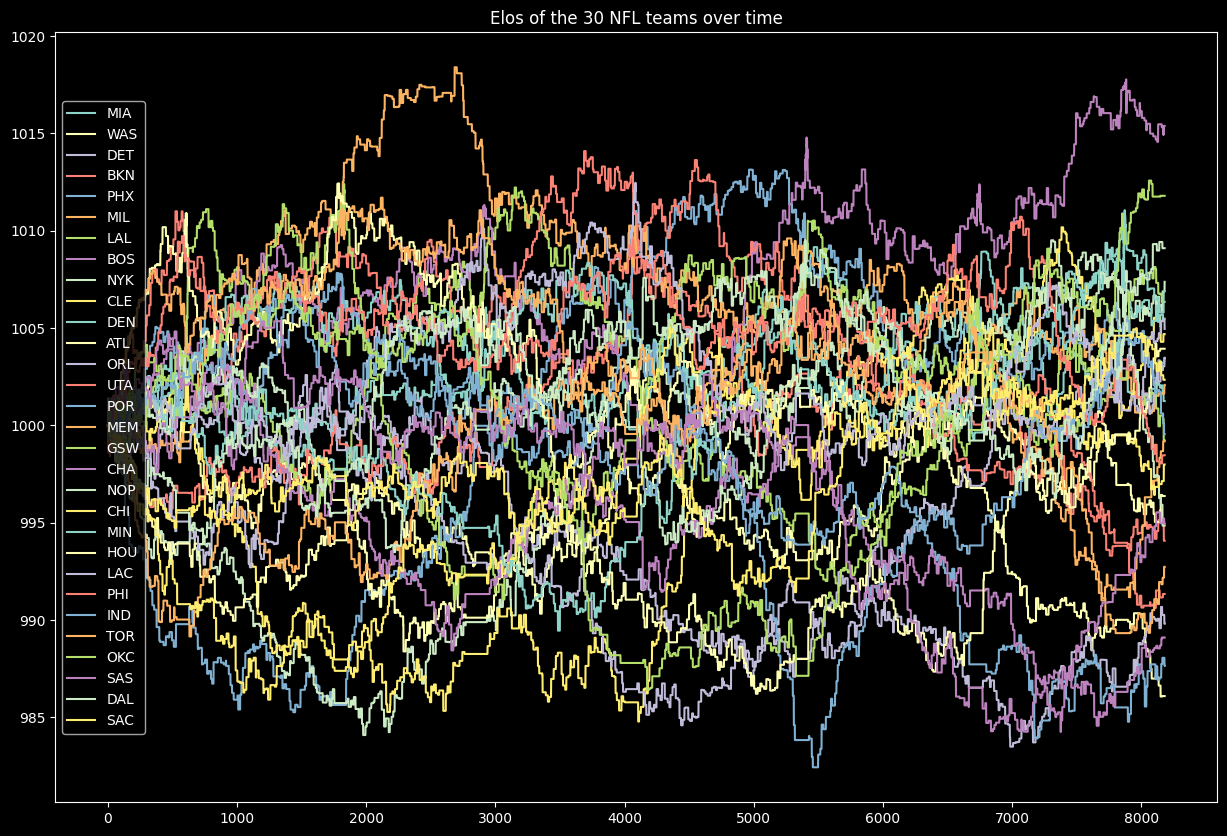

In [107]:
import matplotlib.pyplot as plt

training_elos: dict[str, list[float]] = dict((team, [1000]) for team in set(raw["home"].tolist() + raw["away"].tolist()))

for row in training.itertuples():
    # For each game, calculate the new elos depending on the result and update the old elos.
    # Using points ratio as opposed to pure win/loss is necessary to ensure strength differences
    # are accurately judged (a slim margin of victory should not cause a large elo change).
    new_home, new_away = new_elos(teams[row.home], teams[row.away], row.points_ratio)
    teams[row.home] = new_home
    teams[row.away] = new_away

    for team in training_elos:
        training_elos[team].append(training_elos[team][-1])

    training_elos[row.home][-1] = new_home
    training_elos[row.away][-1] = new_away

# Show teams by elo.
print([ team for team in sorted(teams.items(), key=lambda item: item[1], reverse=True) ])

plt.figure(figsize=(15, 10))
plt.title("Elos of the 30 NFL teams over time")

for team in training_elos:
    plt.plot(training_elos[team], label=team)

plt.legend(loc="center left")
plt.show()

### Backtest

In [108]:
# Calculate expected outcomes and percentage of account to bet for each test game, as well as whether or not the prediction was correct.
predictions: DataFrame = test.copy() # To avoid editing raw test data.
predictions["prob"] = predictions.apply(lambda row: expected_outcome(teams[row["home"]], teams[row["away"]]), axis=1)
predictions.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"])), axis=1)
predictions["kelly_bet"] = predictions.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"]), fraction=0.25), axis=1)
predictions["correct"] = (predictions["points_ratio"] > 0.5) == (predictions["prob"] > 0.5)

#  Calculate account balance at each time step.
balances: list[float] = [ 10_000.0 ]
for row in predictions.itertuples():
    balances.append(balances[-1] + balances[-1] * row.kelly_bet * (1 if row.correct else -1))

### Some Graphs To Visualise Model's Decision Making

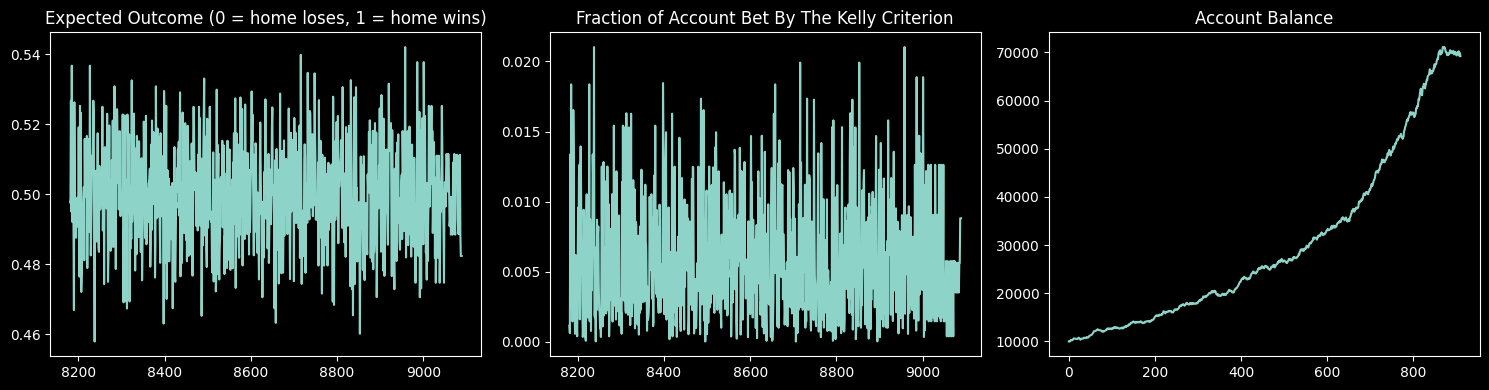

In [109]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(predictions.prob)
axs[0].set_title("Expected Outcome (0 = home loses, 1 = home wins)")

axs[1].plot(predictions.kelly_bet)
axs[1].set_title("Fraction of Account Bet By The Kelly Criterion")

axs[2].plot(balances)
axs[2].set_title("Account Balance")

plt.tight_layout()
plt.show()

###  Evaluation Metrics

In [110]:
# Calculate win rate and final balance.
success: dict[bool, int]   = predictions["correct"].value_counts().to_dict()
win_rate: float            = 100 * success[True] / (success[True] + success[False])
ret: float                 = balances[-1] - balances[0]
returns: float             = ret / balances[0]
series: Series             = Series(balances).pct_change()
avg_ret: float             = series.mean() * 100
stddev_ret: float          = series.std() * 100
stddev_downside_ret: float = Series(filter(lambda ret: ret < 0, series)).std() * 100
kurtosis_ret: float        = series.kurtosis()

max_drawdown: tuple[int, float] = (0, 0)
for i in range(len(balances)):
    for j in range(i + 1, len(balances)):
        diff: float = (balances[j] - balances[i]) / balances[i]

        if diff < max_drawdown[1]:
            max_drawdown = (j - i, diff)

sharpe_ratio: float  = avg_ret / stddev_ret
sortino_ratio: float = avg_ret / stddev_downside_ret
calmar_ratio: float  = returns / -max_drawdown[1]

print(f"Win Rate: {round(win_rate, 2)}%")
print(f"Total Return: {round(ret, 2)} ({round(100 * returns, 2)}%)")
print(f"Mean Bet-To-Bet Return: {round(avg_ret, 2)}%")
print(f"Volatility (standard deviation) of Bet-To-Bet Returns: {round(stddev_ret, 2)}%")
print(f"Downside Volatility of Returns: {round(stddev_downside_ret, 2)}%")
print(f"Kurtosis of Returns: {round(kurtosis_ret, 2)}")
print(f"Maximum Drawdown: {round(max_drawdown[1] * 100, 2)}% over {max_drawdown[0]} games")
print(f"Sharpe Ratio: {sharpe_ratio}")
print(f"Sortino Ratio: {sortino_ratio}")
print(f"Calmar Ratio: {calmar_ratio}")

Win Rate: 61.06%
Total Return: 59220.68 (592.21%)
Mean Bet-To-Bet Return: 0.22%
Volatility (standard deviation) of Bet-To-Bet Returns: 0.69%
Downside Volatility of Returns: 0.36%
Kurtosis of Returns: -0.29
Maximum Drawdown: -5.16% over 12 games
Sharpe Ratio: 0.31338598396249423
Sortino Ratio: 0.6040683350045437
Calmar Ratio: 114.81523681783509
